# 1) Load Data and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score

import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.metrics import accuracy_score

import xgboost as xgb

In [2]:
df = pd.read_csv("sample_to_run_info.csv")

/tmp/ipykernel_1226/2515147133.py:1: DtypeWarning: Columns (22,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_to_run_info.csv")


In [3]:
abundance = pd.read_csv('species_abundance.csv')

# 2) Exploratory Data Analysis & Cleaning

### Work with the Sample to Run Info (df)

In [4]:
# Get rid of all features that have more than 50% of their data missing
thresh = int(len(df) * 0.5)
df = df.dropna(axis=1, thresh=thresh)

In [5]:
# Sneak peek at data
df.head()

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
0,PRJDB3418,NaN,APr10S00,DRR028772,DRS020620,SAMD00024580,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
1,PRJDB3418,NaN,APr14S00,DRR028773,DRS020607,SAMD00024581,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
2,PRJDB3418,NaN,APr15S00,DRR028774,DRS020582,SAMD00024582,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
3,PRJDB3418,NaN,APr21S00,DRR028775,DRS020613,SAMD00024583,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
4,PRJDB3418,NaN,APr24S00,DRR028776,DRS020600,SAMD00024584,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN


In [6]:
# Removed what is determined to be unnecessary
df = df.drop(['more', 'collection_date', 'longitude', 'latitude', 'sample_name', 'original_sample_description', 'sample_id', 'second_sample_id', 'disease'], axis=1)

In [7]:
df.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country
0,PRJDB3418,DRR028772,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
1,PRJDB3418,DRR028773,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
2,PRJDB3418,DRR028774,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
3,PRJDB3418,DRR028775,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
4,PRJDB3418,DRR028776,AMPLICON,3000.0,454 GS FLX,Healthy,Japan


In [8]:
df['phenotype'].value_counts()

,count
phenotype,
Healthy,48241
Colorectal Neoplasms,5543
Crohn Disease,3516
COVID-19,2911
Parkinson Disease,2169
...,...
Colonic Polyps,5
Urolithiasis,5
Dry Eye Syndromes,4


In [9]:
# The phenotypes we will be keeping
keep_phenos = [
    "Healthy",
    "Crohn Disease",
    "Colitis, Ulcerative",
]

df = df[df["phenotype"].isin(keep_phenos)].copy()
print(df["phenotype"].value_counts())

phenotype
Healthy                48241
Crohn Disease           3516
Colitis, Ulcerative     1863
Name: count, dtype: int64


In [10]:
# A stricter filter to keep only the projects which are mainly associated with these phenotypes (Crohn's, UC, and only the healthy patients in projects that collected those two diseases).
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

df = df[df["project_id"].isin(project_ids)].copy()

print(f"Projects with at least one Crohn Disease or Ulcerative Colitis sample: {len(project_ids)}")
print(df["phenotype"].value_counts())

Projects with at least one Crohn Disease or Ulcerative Colitis sample: 46
phenotype
Crohn Disease          3516
Healthy                2099
Colitis, Ulcerative    1863
Name: count, dtype: int64


In [11]:
df['country'].value_counts()

,count
country,
United States of America,3698
China,970
Canada,666
Sweden,637
South Korea,263
Japan,196
Russia,168
Germany,167
India,101


In [12]:
df['experiment_type'].value_counts()

# Amplicon Sequencing is a method that targets and copies specific pieces of DNA
# (amplicons) via PCR to quickly identify which microbes are present in a sample.

# Metagenomic Sequencing is a method that sequences all genetic material directly
# extracted from environmental samples to study the entire microbial community and its functions.

#

print(pd.crosstab(df['phenotype'], df['experiment_type'], normalize='index'))

# There is a decent split between both methods, so likely very little bias

experiment_type      AMPLICON  Metagenomics
phenotype                                  
Colitis, Ulcerative  0.564681      0.435319
Crohn Disease        0.596132      0.403868
Healthy              0.617437      0.382563


In [13]:
# Check whether certain diseases are overrepresented on a given platform for instrument_model.
# As per the counts table, non of them are suspiciously different as there were many other diseases involved
ct_counts = pd.crosstab(df['phenotype'], df['instrument_model'])
ct_counts

instrument_model,454 GS,454 GS FLX Titanium,AB 5500 Genetic Analyzer,AB SOLiD 4 System,HiSeq X Ten,Illumina HiSeq 2000,Illumina HiSeq 2500,Illumina HiSeq 4000,Illumina HiSeq X,Illumina MiSeq,Illumina MiniSeq,Illumina NovaSeq 6000,Ion Torrent PGM
phenotype,,,,,,,,,,,,,
"Colitis, Ulcerative",11,60,0,0,25,709,612,0,0,386,23,27,10
Crohn Disease,10,99,15,7,41,1203,845,42,98,840,0,310,6
Healthy,9,97,0,0,15,1105,285,25,0,357,23,173,10


### Work with the Species Abundance (abundance)

In [14]:
abundance.head()

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.95190,DRR358335
1,2,81104,544,genus,1.07457,DRR358335
2,3,81104,561,genus,0.84957,DRR358335
3,4,81104,570,genus,0.06218,DRR358335
4,5,81104,816,genus,23.29699,DRR358335


In [15]:
abundance['taxon_rank_level'].value_counts()

,count
taxon_rank_level,
genus,2780064
species,2761207


In [16]:
# Keep only species level because it is more specific than genus, allowing us to
# better pinpoint bacteria types and reasoning
abund_species = abundance[abundance["taxon_rank_level"] == "species"].copy()

# Drop rows with ncbi_taxon_id = -1 (unassigned/other)
abund_species = abund_species[abund_species["ncbi_taxon_id"] != -1].copy()

In [17]:
# We take bacteria names and make them columns, and if they exist, their values
# are relative abundances

# Pivot: run_id x ncbi_taxon_id, values = relative_abundance
abund_wide = (
    abund_species
    .pivot_table(index="accession_id",      # this matches run_id in df
                 columns="ncbi_taxon_id",
                 values="relative_abundance",
                 aggfunc="sum",
                 fill_value=0.0)
    .reset_index()
)

# Make column names nicer (e.g., taxon_544, taxon_561, ...)
abund_wide.columns = [
    "run_id" if c == "accession_id" else f"taxon_{int(c)}"
    for c in abund_wide.columns
]

### Merge the data

In [18]:
merged = df.merge(abund_wide, on="run_id", how="inner")

In [19]:
# There was 46 batches before and now there are 12
matched = df.run_id.isin(abund_wide.run_id)
missing = df[~matched]                      # ~ inverts the boolean mask
print("dropped:", len(missing))
print(missing.experiment_type.value_counts())
print(missing.phenotype.value_counts())
print("projects before:", df.project_id.nunique(), "| after:", merged.project_id.nunique())

dropped: 4640
experiment_type
AMPLICON        4444
Metagenomics     196
Name: count, dtype: int64
phenotype
Crohn Disease          2202
Healthy                1366
Colitis, Ulcerative    1072
Name: count, dtype: int64
projects before: 46 | after: 12


In [20]:
merged.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country,taxon_9,taxon_17,taxon_69,...,taxon_2968459,taxon_2968968,taxon_2969304,taxon_2972461,taxon_2972466,taxon_2972769,taxon_2974552,taxon_2974597,taxon_2975484,taxon_2981769
0,PRJEB76677,ERR13295986,Metagenomics,61317544.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,Metagenomics,44948398.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,Metagenomics,7314392.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,Metagenomics,48624378.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,Metagenomics,61732518.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [21]:
# The following features, after EDA, aren't relevant
META_COLS    = ["project_id", "run_id", "phenotype", "experiment_type",
                "instrument_model", "country", "nr_reads_sequenced"]
FEATURE_COLS = [c for c in merged.columns if c.startswith("taxon_")]

# 3) Feature Engineering, Data Splitting, & Label Preparation

In this section we:
1. Create labels for the three phenotypes (Healthy=0, Crohn=1, UC=2)
2. **First split**: Create a train/test split on ALL taxa for L1 feature selection
3. Extract selected features via LASSO

This split approach ensures:
- Feature selection is not biased by the test set used later
- All downstream models use the same clean evaluation split

In [22]:
keep_phenos = ["Healthy", "Crohn Disease", "Colitis, Ulcerative"]
df3 = merged[merged["phenotype"].isin(keep_phenos)].copy()

# We label them to 0, 1, and 2 for multiclass labelling
label_map = {
    "Healthy": 0,
    "Crohn Disease": 1,
    "Colitis, Ulcerative": 2,
}
df3["label"] = df3["phenotype"].map(label_map)

taxon_cols = [c for c in df3.columns if c.startswith("taxon_")]


In [23]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df3, df3["label"], groups=df3["project_id"]))
df_train, df_test = df3.iloc[train_idx], df3.iloc[test_idx]

print("overlap:", set(df_train.project_id) & set(df_test.project_id))  # must be empty
print(df_test.label.value_counts(normalize=True).round(2))

X_train_pd      = df_train[taxon_cols].values
X_test_pd       = df_test[taxon_cols].values

y_train_pd      = df_train["label"].values
y_test_pd       = df_test["label"].values

phenotype_train = df_train["phenotype"].values
phenotype_test  = df_test["phenotype"].values

# Make it so GPU can work with it
X_train = cudf.DataFrame(X_train_pd, columns=taxon_cols)
X_test  = cudf.DataFrame(X_test_pd,  columns=taxon_cols)

y_train = cudf.Series(y_train_pd)
y_test  = cudf.Series(y_test_pd)

overlap: set()
label
1    0.65
0    0.22
2    0.14
Name: proportion, dtype: float64


# 4) GPU L1 Logistic Regression (Feature Selection via LASSO)

Train an L1-regularized logistic regression on all taxa to select a sparse feature set. The union of non-zero coefficients across classes becomes our feature set.

In [24]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = cuLogisticRegression(
    penalty="l1",
    C=0.1,                 # tune for sparsity
    l1_ratio=None,         # pure L1
    fit_intercept=True,
    class_weight="balanced",
    max_iter=5000,
    solver="qn",           # cuML solver
    verbose=0
)

In [25]:
clf.fit(X_train_scaled, y_train)

LogisticRegression()

In [26]:
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("GPU multinomial L1-logreg accuracy:", float(acc))

GPU multinomial L1-logreg accuracy: 0.62


In [27]:
# coef_ is a cuDF DataFrame: shape (n_classes, n_features)
coefs_cudf = clf.coef_

# Convert to pandas / NumPy
coefs = coefs_cudf.to_pandas().to_numpy()   # (n_classes, n_features)

# classes_ is already a NumPy array (e.g., array([0, 1, 2]))
classes = clf.classes_

# Union of non-zero features across classes
nz_any = (coefs != 0).any(axis=0)
selected_taxa_union = np.array(taxon_cols)[nz_any]

print("Total taxa:", len(taxon_cols))
print("Selected by LASSO (any class):", len(selected_taxa_union))

selected_df = pd.DataFrame({
    "taxon": selected_taxa_union,
    "coef_l1_sum": np.abs(coefs[:, nz_any]).sum(axis=0)
}).sort_values("coef_l1_sum", ascending=False)

print(selected_df.head(30))


Total taxa: 2893
Selected by LASSO (any class): 698
             taxon  coef_l1_sum
543  taxon_2292190     0.546810
21       taxon_817     0.527279
546  taxon_2292205     0.473823
529  taxon_2126740     0.392339
372  taxon_1411144     0.365542
572  taxon_2485925     0.348022
104    taxon_28118     0.339047
183    taxon_84026     0.338093
275   taxon_371601     0.334962
232   taxon_208479     0.330041
527  taxon_2093857     0.322774
233   taxon_209880     0.317709
226   taxon_187327     0.314696
688  taxon_2929491     0.311080
611  taxon_2763017     0.310307
126    taxon_33039     0.306758
528  taxon_2108523     0.302670
22       taxon_820     0.299552
345  taxon_1034346     0.296340
9        taxon_562     0.294881
638  taxon_2763675     0.291114
400  taxon_1632013     0.291086
473  taxon_1898207     0.285910
551  taxon_2292271     0.282564
260   taxon_328812     0.278253
296   taxon_487175     0.261272
59      taxon_1531     0.260482
559  taxon_2292991     0.256757
571  taxon_2479840  

In [28]:
# We keep all the features which haven't been minimized to ~0
X_train_lasso = pd.DataFrame(X_train_pd, columns=taxon_cols)[selected_taxa_union]
X_test_lasso  = pd.DataFrame(X_test_pd,  columns=taxon_cols)[selected_taxa_union]

full_lasso = pd.concat(
    [df3.drop(columns=taxon_cols), df3[selected_taxa_union]],
    axis=1
)

In [29]:
full_lasso.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country,label,taxon_167,taxon_201,...,taxon_2929491,taxon_2931401,taxon_2939420,taxon_2941326,taxon_2944914,taxon_2944915,taxon_2951143,taxon_2951805,taxon_2972466,taxon_2981769
0,PRJEB76677,ERR13295986,Metagenomics,61317544.0,Illumina HiSeq 2000,Crohn Disease,Germany,1,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,Metagenomics,44948398.0,Illumina HiSeq 2000,Healthy,Germany,0,0.0,0.0,...,0.24133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,Metagenomics,7314392.0,Illumina HiSeq 2000,Crohn Disease,Germany,1,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,Metagenomics,48624378.0,Illumina HiSeq 2000,Healthy,Germany,0,0.0,0.0,...,0.02524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,Metagenomics,61732518.0,Illumina HiSeq 2000,Crohn Disease,Germany,1,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [30]:
print(full_lasso.shape)
print(full_lasso["phenotype"].value_counts())

(2838, 706)
phenotype
Crohn Disease          1314
Colitis, Ulcerative     791
Healthy                 733
Name: count, dtype: int64


In [31]:
# full_lasso contains selected taxa features and multiclass labels
feature_cols = list(selected_taxa_union)
len(feature_cols)

698

In [32]:
# Shared split for all post-feature-selection models
X_full_np = full_lasso[feature_cols].values
y_full_np = full_lasso["label"].values
phenotype_full = full_lasso["phenotype"].values

# GPU views for cuML models
X_train = cudf.DataFrame(X_train_lasso, columns=feature_cols)
X_test  = cudf.DataFrame(X_test_lasso,  columns=feature_cols)
y_train = cudf.Series(y_train_pd)
y_test  = cudf.Series(y_test_pd)

# Reuse this same split for binary Crohn vs UC, i.e., the binary classification
ibd_train_mask = np.isin(phenotype_train, ["Crohn Disease", "Colitis, Ulcerative"])
ibd_test_mask = np.isin(phenotype_test, ["Crohn Disease", "Colitis, Ulcerative"])

y_train_ibd = (phenotype_train[ibd_train_mask] == "Colitis, Ulcerative").astype(int)
y_test_ibd = (phenotype_test[ibd_test_mask] == "Colitis, Ulcerative").astype(int)

# 5) Random Forest on LASSO-Selected Features

Train a Random Forest classifier on the selected taxa using the shared train/test split.

In [33]:
rf = cuRF(
    n_estimators=300,
    max_depth=20,       # explicit depth for cuML RF
    max_features=1.0,   # fraction of features; 1.0 uses all
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

In [34]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [35]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("GPU RandomForest accuracy:", float(acc))

GPU RandomForest accuracy: 0.68


In [36]:
# Feature importances
importances = rf.feature_importances_
idx = importances.argsort()[::-1]

top_k = 30
top_feats = [(feature_cols[i], importances[i]) for i in idx[:top_k]]

top_importance_df = pd.DataFrame(top_feats, columns=["taxon", "rf_importance"])
print(top_importance_df)

            taxon  rf_importance
0    taxon_745368       0.038201
1   taxon_2981769       0.035384
2   taxon_2485925       0.031807
3     taxon_28118       0.018330
4     taxon_39486       0.018052
5    taxon_371601       0.016845
6   taxon_2293035       0.015101
7   taxon_2885350       0.015092
8    taxon_328814       0.014247
9       taxon_853       0.013180
10  taxon_2929491       0.011903
11  taxon_2292190       0.011731
12   taxon_871665       0.011108
13   taxon_338188       0.009417
14  taxon_2292182       0.009004
15    taxon_39488       0.008975
16  taxon_1912855       0.008827
17      taxon_821       0.008401
18  taxon_1150298       0.007871
19  taxon_1720194       0.007845
20      taxon_820       0.007663
21   taxon_165179       0.007553
22   taxon_360807       0.007412
23  taxon_2606633       0.007265
24   taxon_487175       0.006991
25    taxon_35833       0.006933
26   taxon_649756       0.006862
27   taxon_204516       0.006859
28  taxon_2763670       0.006777
29    taxo

# 6) XGBoost Multiclass (Healthy vs Crohn vs UC)

Train XGBoost for 3-class classification using the same shared train/test split as Random Forest.

In [37]:
# Reuse the shared post-feature-selection split
dtrain = xgb.DMatrix(X_train_lasso, label=y_train)
dtest  = xgb.DMatrix(X_test_lasso,  label=y_test)

In [38]:
params = {
    "objective": "multi:softprob", # Multiclass preds with predicted probabilities
    "num_class": 3,
    "tree_method": "hist",
    "max_depth": 6,
    "eta": 0.1, # Learning rate
    "subsample": 0.8, # 80% of rows will be sampled per tree
    "colsample_bytree": 0.8, # 80% of features are considered when building each tree
    "eval_metric": "mlogloss",
    "device": "cuda", # GPU acceleration
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=30,
    verbose_eval=False,
)

In [39]:
y_proba = bst.predict(dtest)              # shape (n_samples, 3)
y_pred = np.argmax(y_proba, axis=1)

# Support refers to the actual occurrences of each label
print(classification_report(y_test.to_numpy(), y_pred))

              precision    recall  f1-score   support

           0       0.38      0.28      0.32        43
           1       0.74      0.84      0.78       130
           2       0.15      0.11      0.13        27

    accuracy                           0.62       200
   macro avg       0.42      0.41      0.41       200
weighted avg       0.58      0.62      0.60       200



In [40]:
# Macro-averaged ROC-AUC (one-vs-rest)
y_test_oh = np.eye(3)[y_test.to_numpy()]
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr")
print("Macro ROC-AUC:", auc)


Macro ROC-AUC: 0.5790788111921897


In [44]:
importances = bst.get_score(importance_type="gain")
# The keys in 'importances' are already the feature names (e.g., 'taxon_N')
items = []
for k, v in importances.items():
    # 'k' is already the feature name string, e.g., 'taxon_562'
    items.append((k, v))

In [45]:
imp_df = pd.DataFrame(items, columns=["taxon", "gain"]).sort_values("gain", ascending=False)
print(imp_df.head(30))

             taxon       gain
168   taxon_745368  17.217480
289  taxon_2485925  13.594956
308  taxon_2763061  12.387158
66     taxon_39486  12.073008
317  taxon_2763670  11.910459
241  taxon_1965542  11.678384
320  taxon_2763675  11.354864
335  taxon_2841509  11.124493
129   taxon_328814  10.635319
183  taxon_1411144   9.944195
346  taxon_2885350   9.738890
270  taxon_2292190   9.669776
96    taxon_156974   9.370153
300  taxon_2606708   9.147719
250  taxon_2015901   8.708302
220  taxon_1796652   8.549950
98    taxon_163665   7.940202
116   taxon_249188   7.895390
280  taxon_2293035   7.768910
105   taxon_204516   7.536951
82     taxon_54005   7.536759
133   taxon_341225   7.506435
211  taxon_1750560   7.360770
47     taxon_28118   7.273657
140   taxon_371601   7.267730
228  taxon_1871018   7.225707
64     taxon_39483   7.216894
154   taxon_572010   6.917474
304  taxon_2763017   6.911167
213  taxon_1776384   6.790407


# 7) Model Evaluation & Confusion Matrices

Compare predictions from Random Forest and XGBoost on the shared test split.

In [46]:
class_names = ["Healthy", "Crohn", "UC"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(title)
    print(classification_report(y_true, y_pred, target_names=class_names))

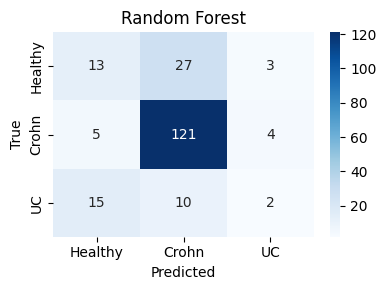

Random Forest
              precision    recall  f1-score   support

     Healthy       0.39      0.30      0.34        43
       Crohn       0.77      0.93      0.84       130
          UC       0.22      0.07      0.11        27

    accuracy                           0.68       200
   macro avg       0.46      0.44      0.43       200
weighted avg       0.61      0.68      0.63       200



In [47]:
# Random Forest confusion matrix on shared test split
y_pred_rf = rf.predict(X_test).to_numpy()
plot_cm(y_test_pd, y_pred_rf, "Random Forest")

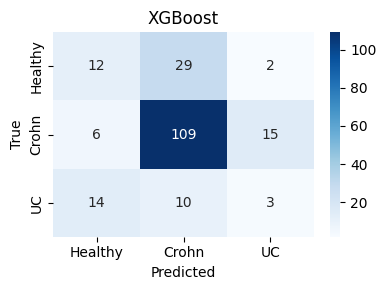

XGBoost
              precision    recall  f1-score   support

     Healthy       0.38      0.28      0.32        43
       Crohn       0.74      0.84      0.78       130
          UC       0.15      0.11      0.13        27

    accuracy                           0.62       200
   macro avg       0.42      0.41      0.41       200
weighted avg       0.58      0.62      0.60       200



In [48]:
y_proba_xgb = bst.predict(dtest)
y_pred_xgb = np.argmax(y_proba_xgb, axis=1)
plot_cm(y_test_pd, y_pred_xgb, "XGBoost")

# 8) Binary Classification: Crohn Disease vs Ulcerative Colitis

Filter to IBD samples only and train binary classifiers (Random Forest and XGBoost). All models use the IBD subset extracted in Section 3's shared split.

In [49]:
# Crohn vs UC only — Healthy excluded.
# Using phenotype strings, not label ints, so the intent is readable.
ibd_train_mask = np.isin(phenotype_train, ["Crohn Disease", "Colitis, Ulcerative"])
ibd_test_mask  = np.isin(phenotype_test,  ["Crohn Disease", "Colitis, Ulcerative"])

# 0 = Crohn, 1 = UC  (matches target_names=["Crohn", "UC"])
y_train_ibd = (phenotype_train[ibd_train_mask] == "Colitis, Ulcerative").astype(int)
y_test_ibd  = (phenotype_test[ibd_test_mask]   == "Colitis, Ulcerative").astype(int)

# Use the pandas frames, not the cudf ones — boolean masks behave predictably here
X_train_ibd = X_train_lasso[ibd_train_mask].reset_index(drop=True)
X_test_ibd  = X_test_lasso[ibd_test_mask].reset_index(drop=True)

In [50]:
print("train:", pd.Series(y_train_ibd).value_counts().to_dict())
print("test: ", pd.Series(y_test_ibd).value_counts().to_dict())
print("shapes:", X_train_ibd.shape, X_test_ibd.shape)

train: {0: 1184, 1: 764}
test:  {0: 130, 1: 27}
shapes: (1948, 698) (157, 698)


In [51]:
# Binary Model: Crohn vs UC (no Healthy) using the shared split from Section 3
print("IBD train distribution (0=Crohn, 1=UC):")
print(pd.Series(y_train_ibd).value_counts().sort_index())
print("\nIBD test distribution (0=Crohn, 1=UC):")
print(pd.Series(y_test_ibd).value_counts().sort_index())

print(f"\nTrain: {len(X_train_ibd)} samples")
print(f"Test:  {len(X_test_ibd)} samples")

IBD train distribution (0=Crohn, 1=UC):
0    1184
1     764
Name: count, dtype: int64

IBD test distribution (0=Crohn, 1=UC):
0    130
1     27
Name: count, dtype: int64

Train: 1948 samples
Test:  157 samples


In [52]:
# Step 1: XGBoost binary

dtrain_ibd = xgb.DMatrix(X_train_ibd, label=y_train_ibd)
dtest_ibd  = xgb.DMatrix(X_test_ibd,  label=y_test_ibd)

params_binary = {
    "objective": "binary:logistic",   # binary now, not multi:softprob
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "auc",             # AUC is best metric for binary
}

bst_ibd = xgb.train(
    params_binary,
    dtrain_ibd,
    num_boost_round=500,
    evals=[(dtrain_ibd, "train"), (dtest_ibd, "test")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

[0]	train-auc:0.82561	test-auc:0.67906
[38]	train-auc:0.98292	test-auc:0.71994


XGBoost — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.83      0.92      0.88       130
          UC       0.23      0.11      0.15        27

    accuracy                           0.78       157
   macro avg       0.53      0.52      0.51       157
weighted avg       0.73      0.78      0.75       157

ROC-AUC: 0.7199


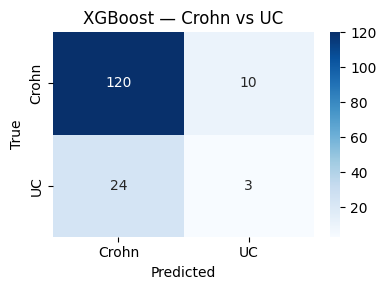

In [53]:
# Step 2: Evaluate XGBoost binary
y_proba_ibd = bst_ibd.predict(dtest_ibd)
y_pred_ibd  = (y_proba_ibd > 0.5).astype(int)

print("XGBoost — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_ibd, target_names=["Crohn", "UC"]))
print(f"ROC-AUC: {roc_auc_score(y_test_ibd, y_proba_ibd):.4f}")

# Use a separate plot function for binary — don't use plot_cm

def plot_cm_binary(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Crohn", "UC"],
                yticklabels=["Crohn", "UC"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm_binary(y_test_ibd, y_pred_ibd, "XGBoost — Crohn vs UC")

Random Forest — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.86      0.89      0.88       130
          UC       0.36      0.30      0.33        27

    accuracy                           0.79       157
   macro avg       0.61      0.59      0.60       157
weighted avg       0.77      0.79      0.78       157



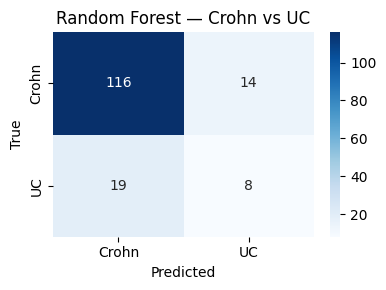

In [54]:
# Step 3: Random Forest binary
rf_ibd = cuRF(
    n_estimators=300,
    max_depth=20,
    max_features=1.0,
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

X_train_ibd_gpu = cudf.DataFrame(X_train_ibd, columns=feature_cols)
X_test_ibd_gpu  = cudf.DataFrame(X_test_ibd,  columns=feature_cols)
y_train_ibd_gpu = cudf.Series(y_train_ibd)
y_test_ibd_gpu  = cudf.Series(y_test_ibd)

rf_ibd.fit(X_train_ibd_gpu, y_train_ibd_gpu)
y_pred_rf_ibd = rf_ibd.predict(X_test_ibd_gpu)

print("Random Forest — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_rf_ibd.to_numpy(), target_names=["Crohn", "UC"]))

plot_cm_binary(y_test_ibd, y_pred_rf_ibd.to_numpy(), "Random Forest — Crohn vs UC")

Default threshold (0.5): F1 = 0.1500
Optimal threshold (0.36): F1 = 0.4419

Tuned threshold results:
              precision    recall  f1-score   support

       Crohn       0.91      0.69      0.79       130
          UC       0.31      0.67      0.42        27

    accuracy                           0.69       157
   macro avg       0.61      0.68      0.60       157
weighted avg       0.81      0.69      0.72       157



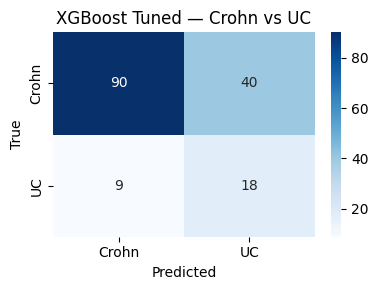

In [55]:
# Step 4: Threshold tuning — find optimal cutoff for UC recall
precisions, recalls, thresholds = precision_recall_curve(y_test_ibd, y_proba_ibd)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores.argmax()]

print(f"Default threshold (0.5): F1 = {f1_score(y_test_ibd, (y_proba_ibd > 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}): F1 = {f1_scores.max():.4f}")

# Apply optimal threshold
y_pred_tuned = (y_proba_ibd > best_thresh).astype(int)
print("\nTuned threshold results:")
print(classification_report(y_test_ibd, y_pred_tuned, target_names=["Crohn", "UC"]))
plot_cm_binary(y_test_ibd, y_pred_tuned, "XGBoost Tuned — Crohn vs UC")